<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 109 · Feature Selection</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Feature Selection</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Keeping the signal and dropping the noise on a marketing table where only 5 of 16 features matter: filter (F-score, mutual information), wrapper (RFE / RFECV), and embedded (lasso, tree importances) methods, the fewer-features-same-accuracy payoff, and the selection-leakage trap, all library-first and visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Feature Selection: keep the signal, drop the noise
More columns is not more information. Irrelevant and redundant features add noise, slow training, and invite overfitting. This notebook works the three families of **feature selection**, **filter** (score each feature), **wrapper** (search subsets with a model), and **embedded** (selection during training, lasso and tree importances), on a marketing table where only 5 of 16 features actually matter, and ends with the leakage trap that silently inflates results. Library-first with `scikit-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, RFECV, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
pd.set_option('display.max_columns', 40)

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 &#183; THE PROBLEM: TOO MANY FEATURES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">16 columns, but which ones matter?</div>
<div style="color:#4a5578;margin-top:6px">Only a handful carry real signal.</div>
</div>

In [3]:
try: df = pd.read_excel('../../data/ch109_campaign.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'ch109_campaign.xlsx', sheet_name='Data')
feat = [c for c in df.columns if c not in ('customer_id','responded')]
X, y = df[feat], df['responded']
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
print(f'{len(feat)} candidate features, {len(df)} rows, response rate {y.mean():.0%}')
print(f'model on ALL {len(feat)} features: 5-fold CV accuracy = {cross_val_score(clf, X, y, cv=5).mean():.3f}')

16 candidate features, 900 rows, response rate 51%
model on ALL 16 features: 5-fold CV accuracy = 0.774


**The setup.** We have **16 candidate features** but no idea yet which ones matter. In truth (by construction) only **five are informative** (recency, frequency, monetary, email open rate, web visits), **three are redundant** copies of those, and **eight are pure noise**, but a real analyst does not know that in advance. Feature selection is how we find out, and the payoff is a simpler, faster, more robust model.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; FILTER METHODS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Score each feature against the target</div>
<div style="color:#4a5578;margin-top:6px">Fast, model-agnostic, computed before any model.</div>
</div>

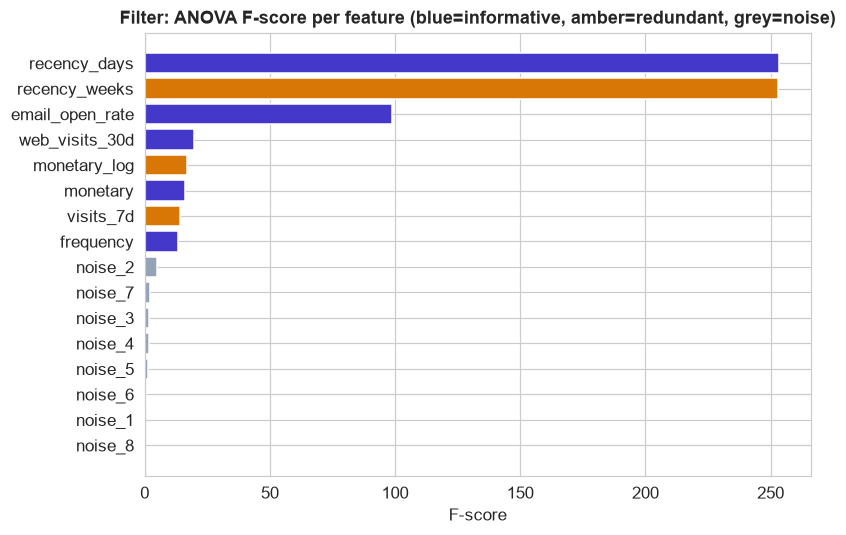

top 6 by mutual information: ['recency_weeks', 'recency_days', 'email_open_rate', 'visits_7d', 'web_visits_30d', 'noise_8']


In [4]:
fscore = pd.Series(f_classif(X, y)[0], index=feat).sort_values()
mi = pd.Series(mutual_info_classif(X, y, random_state=0), index=feat)
fig, ax = plt.subplots(figsize=(7.6,5))
colors = [GREY if ('noise' in f) else (AMBER if f in ('recency_weeks','monetary_log','visits_7d') else EM) for f in fscore.index]
ax.barh(fscore.index, fscore.values, color=colors)
ax.set(title='Filter: ANOVA F-score per feature (blue=informative, amber=redundant, grey=noise)', xlabel='F-score'); plt.tight_layout(); plt.show()
print('top 6 by mutual information:', list(mi.sort_values(ascending=False).head(6).index))

**What the code does.** A **filter** scores each feature's relationship with the target on its own, here the **ANOVA F-score** and **mutual information**, with no model involved, so it is fast and works as a first pass. The bar chart is decisive: the informative features and their redundant copies score high, and the eight `noise` columns sit near zero. The catch: filters rank features **independently**, so they cannot tell that `recency_weeks` is just a copy of `recency_days`, both score high. Detecting redundancy needs the next two families.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; WRAPPER METHODS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Let a model search for the best subset</div>
<div style="color:#4a5578;margin-top:6px">Recursive feature elimination, cross-validated.</div>
</div>

RFECV chose 8 features: ['recency_days', 'frequency', 'monetary', 'email_open_rate', 'web_visits_30d', 'recency_weeks', 'monetary_log', 'visits_7d']


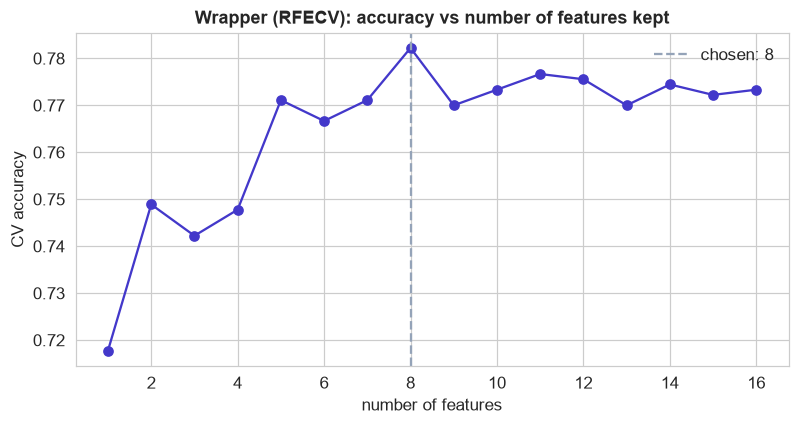

In [5]:
Xs = StandardScaler().fit_transform(X)
rfecv = RFECV(LogisticRegression(max_iter=1000), step=1, cv=5, scoring='accuracy').fit(Xs, y)
print(f'RFECV chose {rfecv.n_features_} features:', [feat[i] for i in np.where(rfecv.support_)[0]])
fig, ax = plt.subplots(figsize=(7.4,4))
ax.plot(range(1, len(feat)+1), rfecv.cv_results_['mean_test_score'], 'o-', color=EM)
ax.axvline(rfecv.n_features_, color=GREY, ls='--', label=f'chosen: {rfecv.n_features_}')
ax.set(title='Wrapper (RFECV): accuracy vs number of features kept', xlabel='number of features', ylabel='CV accuracy'); ax.legend()
plt.tight_layout(); plt.show()

**What the code does.** A **wrapper** actually trains a model on different feature subsets and keeps the best. **Recursive feature elimination (RFE)** fits the model, drops the least useful feature, and repeats; **RFECV** cross-validates each subset size and picks the sweet spot. The curve shows accuracy **rising steeply as the first informative features go in, then flattening**, adding the noise columns brings no gain. Wrappers are more accurate than filters (they account for feature interactions and redundancy) but far slower, since they refit the model many times.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 4 &#183; EMBEDDED METHODS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Selection built into the model</div>
<div style="color:#4a5578;margin-top:6px">L1 (lasso) zeros features; trees rank them.</div>
</div>

L1 logistic zeroed 4 of 16 features: ['noise_1', 'noise_6', 'noise_7', 'noise_8']


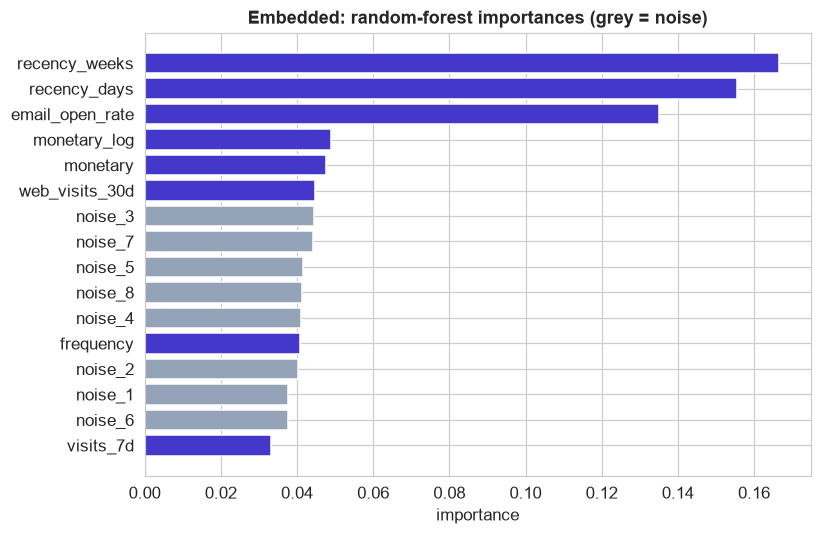

In [6]:
l1 = make_pipeline(StandardScaler(), LogisticRegression(penalty='l1', solver='liblinear', C=0.12, max_iter=2000)).fit(X, y)
coef = pd.Series(np.abs(l1[-1].coef_[0]), index=feat)
zeroed = [f for f in feat if coef[f] < 1e-6]
print(f'L1 logistic zeroed {len(zeroed)} of {len(feat)} features:', zeroed)
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(X, y)
imp = pd.Series(rf.feature_importances_, index=feat).sort_values()
fig, ax = plt.subplots(figsize=(7.6,5))
ax.barh(imp.index, imp.values, color=[GREY if 'noise' in f else EM for f in imp.index])
ax.set(title='Embedded: random-forest importances (grey = noise)', xlabel='importance'); plt.tight_layout(); plt.show()

**What the code does.** **Embedded** methods select as a side effect of training. **L1 (lasso) regularization** on the logistic model shrinks weak coefficients to **exactly zero**, dropping most of the noise and redundant columns automatically (the Chapter 103 idea, now used for selection). **Tree ensembles** expose `feature_importances_`, which rank the informative features at the top and the noise near the bottom. Embedded methods give the best accuracy-per-effort: selection and modeling happen together, in a single fit.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; FEWER FEATURES, SAME ACCURACY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The payoff of selection</div>
<div style="color:#4a5578;margin-top:6px">A lean model can match the full one.</div>
</div>

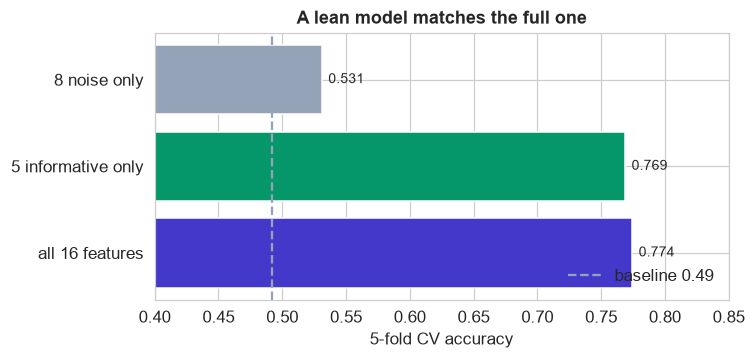

In [7]:
info = ['recency_days','frequency','monetary','email_open_rate','web_visits_30d']
noise_only = [f for f in feat if 'noise' in f]
res = {f'all {len(feat)} features': cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X, y, cv=5).mean(),
       f'5 informative only': cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X[info], y, cv=5).mean(),
       '8 noise only': cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X[noise_only], y, cv=5).mean()}
s = pd.Series(res)
fig, ax = plt.subplots(figsize=(7,3.4))
ax.barh(s.index, s.values, color=[EM, GREEN, GREY])
ax.axvline(1-y.mean(), color=GREY, ls='--', label=f'baseline {1-y.mean():.2f}')
for i,v in enumerate(s.values): ax.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set(title='A lean model matches the full one', xlabel='5-fold CV accuracy', xlim=(0.4,0.85)); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**The payoff.** Using only the **5 informative features** scores essentially the same as using all 16, the eleven noise and redundant columns added **nothing**. Meanwhile a model built only from the eight `noise` columns lands at the coin-flip **baseline**, confirming they carry no signal. A leaner model is faster to train and serve, easier to explain, cheaper to collect data for, and less prone to overfitting, all for no loss in accuracy.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 6 &#183; THE SELECTION LEAKAGE TRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Select inside cross-validation, never before it</div>
<div style="color:#4a5578;margin-top:6px">Choosing features on the whole dataset fakes success.</div>
</div>

In [8]:
rng = np.random.default_rng(0)
X_junk = pd.DataFrame(rng.normal(size=(len(y), 300)), columns=[f'j{i}' for i in range(300)])   # 300 pure-noise columns
# WRONG: pick the 5 'best' junk columns using the WHOLE dataset, then cross-validate
best5 = SelectKBest(f_classif, k=5).fit(X_junk, y).get_support(indices=True)
leaky = cross_val_score(LogisticRegression(max_iter=1000), X_junk.iloc[:, best5], y, cv=5).mean()
# RIGHT: put the selection inside a Pipeline so it is refit within each fold
honest = cross_val_score(Pipeline([('sel', SelectKBest(f_classif, k=5)), ('lr', LogisticRegression(max_iter=1000))]), X_junk, y, cv=5).mean()
print(f'selecting on all data, then CV : {leaky:.3f}   <- looks predictive, but it is pure noise')
print(f'selection inside the pipeline  : {honest:.3f}   <- honest, at the coin-flip baseline')

selecting on all data, then CV : 0.561   <- looks predictive, but it is pure noise
selection inside the pipeline  : 0.484   <- honest, at the coin-flip baseline


**The trap.** Feature selection is a **decision made from the data**, so it must live **inside** cross-validation, exactly like the preprocessing in Chapter 105. Here we hand the model **300 columns of pure noise**. If we pick the five that correlate best with the target using the *whole* dataset and then cross-validate, we get a falsely high score, because the selection already peeked at every fold. Wrapping the selector in a **`Pipeline`** so it is refit within each fold gives the honest answer: **baseline**, because noise is noise. Selecting features before the split is one of the most common ways people fool themselves.

## Choosing a selection method

- **Filter** (F-score, mutual information, correlation): fast and model-free, a good first screen, but blind to redundancy and interactions.
- **Wrapper** (RFE / RFECV, forward/backward selection): most accurate, accounts for interactions, but slow (refits the model many times).
- **Embedded** (L1 / lasso, tree importances): selection during training, the best accuracy-per-compute; the everyday default.
- **Always select inside the cross-validation / pipeline**, choosing features on the full dataset leaks the answer and inflates your score.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>